<a href="https://colab.research.google.com/github/pratyushkr1367/emotion-detection-cnn/blob/main/emotion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving emotion-detection-fer.zip to emotion-detection-fer.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d ananthu017/emotion-detection-fer
!unzip emotion-detection-fer.zip -d emotion_data


Streaming output truncated to the last 5000 lines.
  inflating: emotion_data/train/sad/im37.png  
  inflating: emotion_data/train/sad/im370.png  
  inflating: emotion_data/train/sad/im3700.png  
  inflating: emotion_data/train/sad/im3701.png  
  inflating: emotion_data/train/sad/im3702.png  
  inflating: emotion_data/train/sad/im3703.png  
  inflating: emotion_data/train/sad/im3704.png  
  inflating: emotion_data/train/sad/im3705.png  
  inflating: emotion_data/train/sad/im3706.png  
  inflating: emotion_data/train/sad/im3707.png  
  inflating: emotion_data/train/sad/im3708.png  
  inflating: emotion_data/train/sad/im3709.png  
  inflating: emotion_data/train/sad/im371.png  
  inflating: emotion_data/train/sad/im3710.png  
  inflating: emotion_data/train/sad/im3711.png  
  inflating: emotion_data/train/sad/im3712.png  
  inflating: emotion_data/train/sad/im3713.png  
  inflating: emotion_data/train/sad/im3714.png  
  inflating: emotion_data/train/sad/im3715.png  
  inflating: emotion_d

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
train_dir = "/content/emotion_data/train"
test_dir = "/content/emotion_data/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical",
    shuffle=False
)



Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(48,48,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)




In [ ]:
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[lr_reduce]
)


Epoch 1/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 595s 1s/step - accuracy: 0.2732 - loss: 1.9506 - val_accuracy: 0.3635 - val_loss: 1.6489 - learning_rate: 5.0000e-04
Epoch 2/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 570s 1s/step - accuracy: 0.3333 - loss: 1.7266 - val_accuracy: 0.4071 - val_loss: 1.6342 - learning_rate: 5.0000e-04
Epoch 3/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 582s 1s/step - accuracy: 0.3896 - loss: 1.5661 - val_accuracy: 0.4549 - val_loss: 1.4451 - learning_rate: 5.0000e-04
Epoch 4/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 583s 1s/step - accuracy: 0.4244 - loss: 1.4823 - val_accuracy: 0.4937 - val_loss: 1.3363 - learning_rate: 5.0000e-04
Epoch 5/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 575s 1s/step - accuracy: 0.4506 - loss: 1.4204 - val_accuracy: 0.4940 - val_loss: 1.2989 - learning_rate: 5.0000e-04
Epoch 6/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 580s 1s/step - accuracy: 0.4668 - loss: 1.3835 - val_accuracy: 0.5368 - val_loss: 1.2107 - learning_rate: 5.0000e-04
Epoch 7/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 578s 1s/step - acc

In [ ]:
model.save("emotion_cnn_model.keras")
print("Model saved successfully!")


Model saved successfully!


In [ ]:
from keras.optimizers import Adam

# Load model
model = keras.models.load_model("/content/emotion_cnn_model.keras")

# Re-compile (required for evaluation)
model.compile(
    optimizer=Adam(learning_rate=0.0007),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Now evaluation will work
val_loss, val_acc = model.evaluate(val_generator)
print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


113/113 ━━━━━━━━━━━━━━━━━━━━ 36s 309ms/step - accuracy: 0.1737 - loss: 1.9530
Validation Accuracy: 0.17177486419677734
Validation Loss: 1.9528096914291382


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict
pred_probs = model.predict(test_data)
pred_labels = np.argmax(pred_probs, axis=1)

true_labels = test_data.classes

# Print classification report
print(classification_report(
    true_labels,
    pred_labels,
    target_names=list(test_data.class_indices.keys())
))


113/113 ━━━━━━━━━━━━━━━━━━━━ 33s 287ms/step
              precision    recall  f1-score   support

       angry       1.00      0.00      0.00       958
   disgusted       0.00      0.00      0.00       111
     fearful       0.00      0.00      0.00      1024
       happy       0.00      0.00      0.00      1774
     neutral       0.17      1.00      0.29      1233
         sad       0.00      0.00      0.00      1247
   surprised       0.00      0.00      0.00       831

    accuracy                           0.17      7178
   macro avg       0.17      0.14      0.04      7178
weighted avg       0.16      0.17      0.05      7178



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


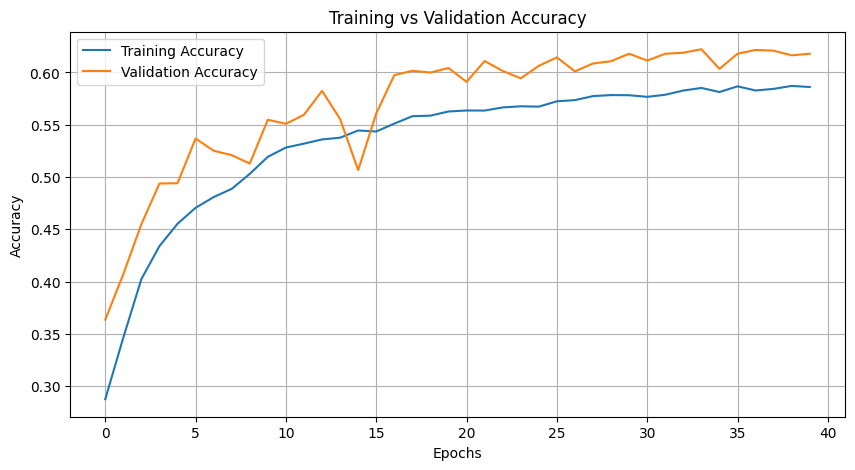

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


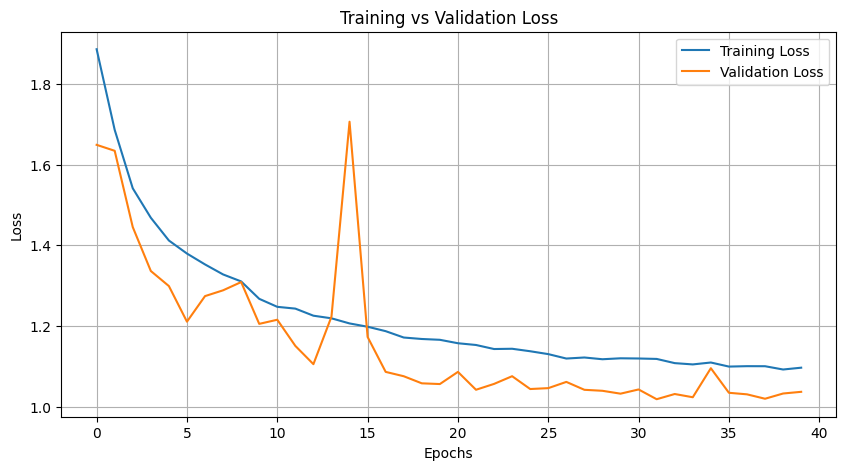

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



113/113 ━━━━━━━━━━━━━━━━━━━━ 29s 254ms/step


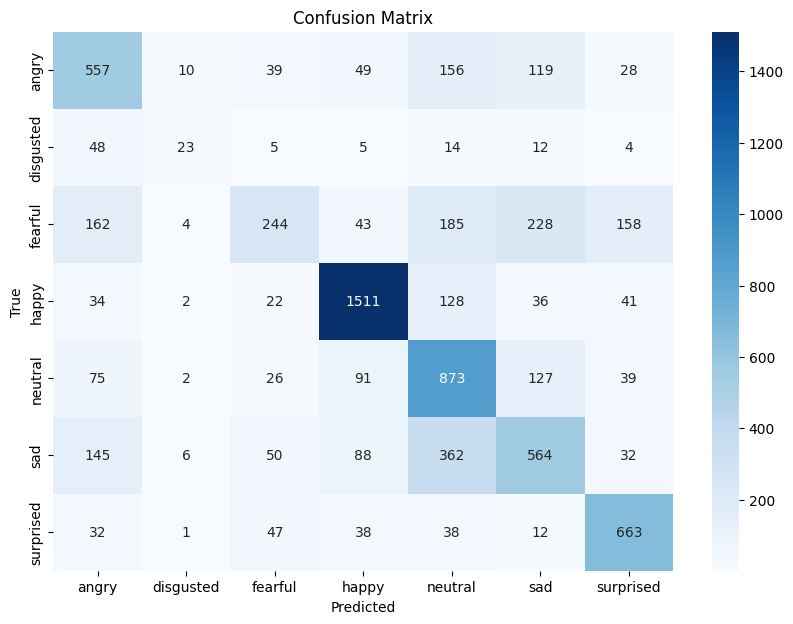

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# predictions
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

# true labels
y_true = test_data.classes

# confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.class_indices.keys(),
            yticklabels=test_data.class_indices.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=test_data.class_indices.keys()
))

              precision    recall  f1-score   support

       angry       0.53      0.58      0.55       958
   disgusted       0.48      0.21      0.29       111
     fearful       0.56      0.24      0.33      1024
       happy       0.83      0.85      0.84      1774
     neutral       0.50      0.71      0.58      1233
         sad       0.51      0.45      0.48      1247
   surprised       0.69      0.80      0.74       831

    accuracy                           0.62      7178
   macro avg       0.59      0.55      0.55      7178
weighted avg       0.62      0.62      0.60      7178



In [ ]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# Load your saved model
model = load_model("/content/emotion_cnn_model.keras")

# Emotion labels (same order as your generator classes)
class_names = ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

def predict_emotion(img_path):
    # Read image
    img = cv2.imread(img_path)

    # Convert to grayscale
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize to 48x48
    img_resized = cv2.resize(img_gray, (48, 48))

    # Normalize
    img_norm = img_resized / 255.0

    # Reshape for model: (1,48,48,1)
    img_input = np.expand_dims(img_norm, axis=0)
    img_input = np.expand_dims(img_input, axis=-1)

    # Predict
    preds = model.predict(img_input)
    class_idx = np.argmax(preds)
    emotion = class_names[class_idx]

    print("Predicted Emotion:", emotion)

# Test with your uploaded image
predict_emotion("/content/angry2.jpg")



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
Predicted Emotion: angry
